# Simple All-Viral and Respiratory Models 

- **Summary**: This document estimates all-viral and respiratory models via an exceedance probability function for pandemic severeity and a gamma distribution for pandemic duration.

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Oct 15, 2024

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.integrate import quad
from scipy.stats import lognorm, genpareto 
from scipy.optimize import minimize


## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## 0. Prepare respiratory viral epidemic data

In [22]:
## Read epidemic data from Marani et al. 
df = pd.read_excel("data/epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

In [23]:
## Subset data to 1900-present
yrmin = 1900
df = df[(df["year_start"] >= yrmin)].reset_index(drop=True)

In [24]:
## Subset to threshold-exceeding pandemics
thresh = 0.01  ## Set threshold to 0.01 SMU
# thresh = 0.1  ## Set threshold to 0.1 SMU

df = df[(df["severity_smu"] >= thresh)]

In [25]:
## Subset to all novel viral pandemics
df_all = df[df['disease'].isin(['influenza', 'covid-19', 'ebola', 'hiv/aids'])
           ].reset_index(drop=True)

# df_all = df_all[df_all['duration'] != 44].reset_index()

## Subset to respiratory viral pandemics
df_resp = df[df['disease'].isin(['influenza', 'covid-19'])
            ].reset_index(drop=True)

In [26]:
## Display datasets of interest
print("Novel Viral Pandemics")
df_all
print()

print("Novel Respiratory Pandemics")
df_resp 
print()

Novel Viral Pandemics


,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,pandemic spanish flu,1918,1920,3,32000.000,1873300.000,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
1,pandemic of asian flu,1957,1958,2,2000.000,2873306.000,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
2,hong kong flu,1968,1969,2,1000.000,3551599.000,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
3,hiv/aids pandemic,1981,2024,44,42300.000,4536996.619,9.323348,93.233484,hiv/aids,viral,fluid,1,0,1,1
4,swine flu,2009,2009,1,284.500,6872767.000,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
5,western africa,2013,2016,4,11.325,7210582.000,0.001571,0.015706,ebola,viral,blood/fluid,1,0,1,1
6,global covid-19,2019,2024,6,7100.000,7740000.000,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1



Novel Respiratory Pandemics


,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,pandemic spanish flu,1918,1920,3,32000.0,1873300.0,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
1,pandemic of asian flu,1957,1958,2,2000.0,2873306.0,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
2,hong kong flu,1968,1969,2,1000.0,3551599.0,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
3,swine flu,2009,2009,1,284.5,6872767.0,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
4,global covid-19,2019,2024,6,7100.0,7740000.0,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


## 1. Set up exceedance probabilities for all and respiratory models

In [27]:
## Set severeity points automatically
plot_madhav_points = False  ## CHANGE METHOD HERE

if plot_madhav_points:
    severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
else:
    ## Linear grid between 0.01 and 280
    # severity = np.linspace(0.01, 280, 200).tolist()  # 200 evenly spaced points

    ## Logarithmic spacing for more granularity
    severity = np.logspace(np.log10(0.01), np.log10(280), 200).tolist()


## Set severeity points automatically 
# plot_madhav_points = False  ## CHANGE METHOD HERE

# if plot_madhav_points:
#     severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
# else:
#     severity = [0.01, 0.04, 0.07, 0.08, 0.1, 0.4, 0.7, 1, 4, 7, 8, 10, 
#                 15, 20, 28, 40, 45, 70, 86, 100, 120, 150, 170, 190, 
#                 200, 220, 230, 240, 250, 260, 270, 280]

In [28]:
## Fit generalized Pareto distribution on severities
params_all = genpareto.fit(df_all['severity_smu'], floc=thresh)

## Print results
print(*params_all)

2.504882508798669 0.01 1.7457313371472198


In [29]:
## Find arrival rate of threshold-exceeding epidemics during the past 20 years (2005 to 2024)
arrival_all = df_all[(df_all['year_start'] >= 2005) & 
                (df_all['year_start'] <= 2024)
                ].shape[0] / (2024 - 2005 + 1)

## Print arrival rate of threshold-exceeding events
print(f'All novel viral pandemic arrival rate: {round(arrival_all, 3)}/year')

All novel viral pandemic arrival rate: 0.15/year


In [30]:
## Calculate exceedance probabilities
exceedance_all = arrival_all * (1 - genpareto.cdf(severity, *params_all))


In [31]:
## Fit generalized Pareto distribution on severities
params_resp = genpareto.fit(df_resp['severity_smu'], floc=thresh)

## Print results
print(*params_resp)

1.3911490201494356 0.01 4.919578645628762


In [32]:
## Find arrival rate of threshold-exceeding epidemics during the past 20 years (2005 to 2024)
arrival_resp = df_resp[(df_resp['year_start'] >= 2005) & 
                (df_resp['year_start'] <= 2024)
                ].shape[0] / (2024 - 2005 + 1)

## Print arrival rate of threshold-exceeding events
print(f'All novel viral pandemic arrival rate: {round(arrival_resp, 3)}/year')

All novel viral pandemic arrival rate: 0.1/year


In [33]:
## Calculate exceedance probabilities
exceedance_resp = arrival_resp * (1 - genpareto.cdf(severity, *params_resp))


In [34]:
df_exceedance = pd.DataFrame({
    "severity": severity,
    "exceedance_all": exceedance_all,
    "exceedance_resp": exceedance_resp
})

df_exceedance.head()

,severity,exceedance_all,exceedance_resp
0,0.010000,0.150000,0.100000
1,0.010528,0.149955,0.099989
2,0.011084,0.149907,0.099978
3,0.011669,0.149857,0.099966
4,0.012285,0.149804,0.099954


In [35]:
## Read Madhav exceedance results from '03_resp_viral_comp'
df_madhav = pd.read_excel("exceedance_results/madhav_original.xlsx")

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people)')

Text(0, 0.5, 'Annual exceedance probability (log scale)')

(0.0001, 1.0)

(0.0, 300.0)

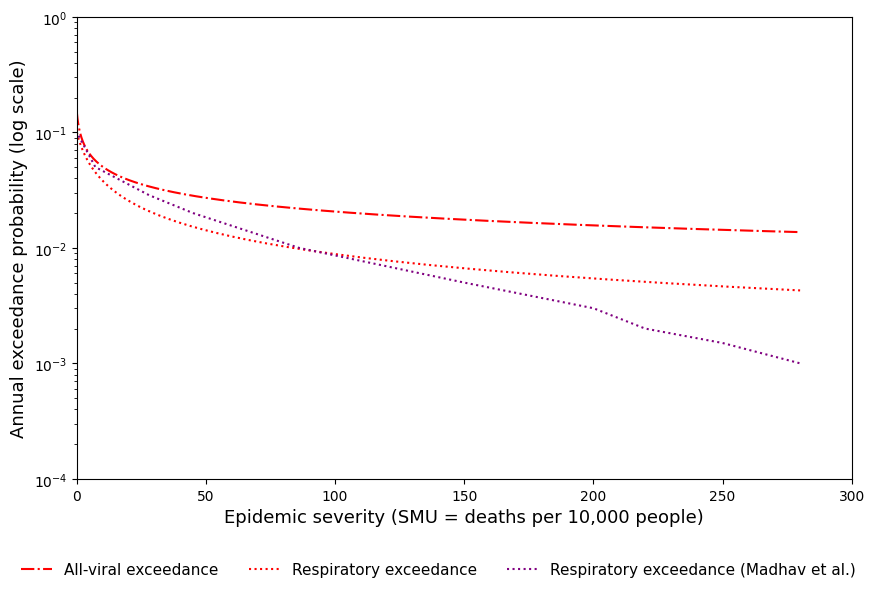

In [36]:
## Plot comparison across Marani with different thresholds 
plt.figure(figsize=(10, 6))

## Plot for all viral with 0.01 SMU threshold
plt.plot(df_exceedance['severity'], df_exceedance['exceedance_all'], 
         color='red', linestyle='-.', alpha=1,
         label='All-viral exceedance')


## Plot for resp with 0.01 SMU threshold
plt.plot(df_exceedance['severity'], df_exceedance['exceedance_resp'], 
         color='red', linestyle=':', alpha=1,
         label='Respiratory exceedance')



## Plot for cov with 0.01 SMU threshold
# plt.plot(df_cov['severity'], df_cov['exceedance_cov'], 
#          color='red', linestyle='--', alpha=1,
#          label='Coronavirus exceedance')


## Plot for Madhav
plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
         color='purple', linestyle=':', label='Respiratory exceedance (Madhav et al.) ')


## Add labels and title
# plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual exceedance probability (log scale)', fontsize=13)
# plt.title('Coronavirus Exceedance', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis scale and limits
# plt.xscale('log')
# plt.xlim(1e-2, 1e3)
plt.xlim(0, 300)

## Adding legend below the plot in 'ncol' column(s) without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=3, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
# plt.savefig('graphs/11_exceedance_comp.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()


<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Annual exceedance probability (log scale)')

(0.0001, 1.0)

(0.01, 1000.0)

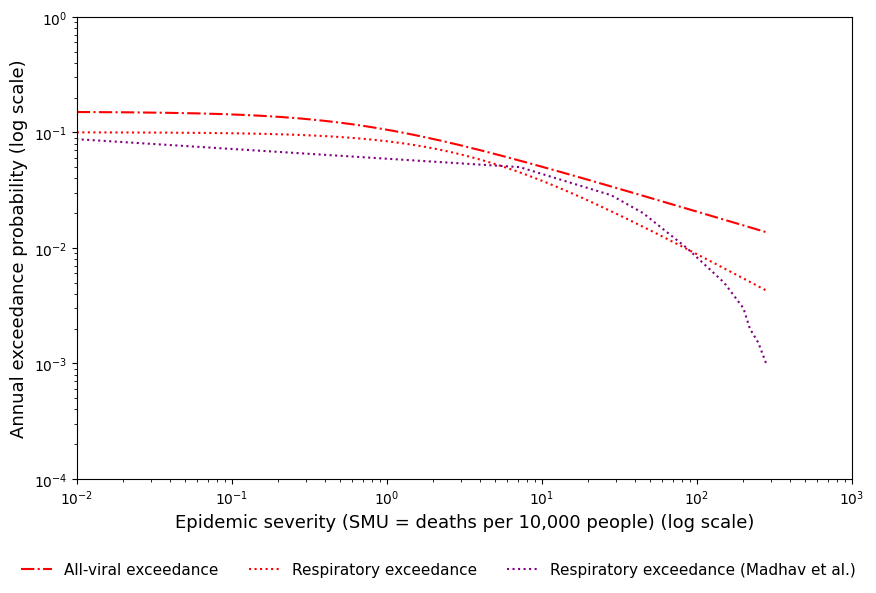

In [37]:
## Plot comparison across Marani with different thresholds 
plt.figure(figsize=(10, 6))

## Plot for all viral with 0.01 SMU threshold
plt.plot(df_exceedance['severity'], df_exceedance['exceedance_all'], 
         color='red', linestyle='-.', alpha=1,
         label='All-viral exceedance')

## Plot for resp with 0.01 SMU threshold
plt.plot(df_exceedance['severity'], df_exceedance['exceedance_resp'], 
         color='red', linestyle=':', alpha=1,
         label='Respiratory exceedance')

## Plot for Madhav
plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
         color='purple', linestyle=':', label='Respiratory exceedance (Madhav et al.) ')


## Add labels and title
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
# plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual exceedance probability (log scale)', fontsize=13)
# plt.title('Coronavirus Exceedance', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-2, 1e3)
# plt.xlim(0, 300)

## Adding legend below the plot in 'ncol' column(s) without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=3, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
# plt.savefig('graphs/11_exceedance_comp_log.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()


## 2. Set up log-normal fits for all and respiratory duration

In [38]:
## Set up minimum duration truncation
duration_min = 0

## generate linespace for duration densities
x = np.linspace(0, 20, 1000)  ## Set 20 years max

## Fit log-normal distribution for all-viral durations 
shape, loc, scale = lognorm.fit(df_all['duration'], floc = duration_min) 
print("All-Viral:")
print(shape, loc, scale)

pdf_all = lognorm.pdf(x, s=shape,loc=loc, scale=scale)

## Fit log-normal distribution for respiratory durations 
shape, loc, scale = lognorm.fit(df_resp['duration'], floc = duration_min) 
print("Respiratory:")
print(shape, loc, scale)

pdf_resp = lognorm.pdf(x, s=shape,loc=loc, scale=scale)



All-Viral:
1.125696848123989 0 3.8558553899406847
Respiratory:
0.5865632728886827 0 2.352158045049347


<Figure size 1000x600 with 0 Axes>

([<matplotlib.axis.XTick at 0x14406a310>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20')])

(0.0, 0.35)

(0.0, 20.0)

Text(0, 0.5, 'Log-normal PDF')

Text(0.5, 0, 'Duration (year)')

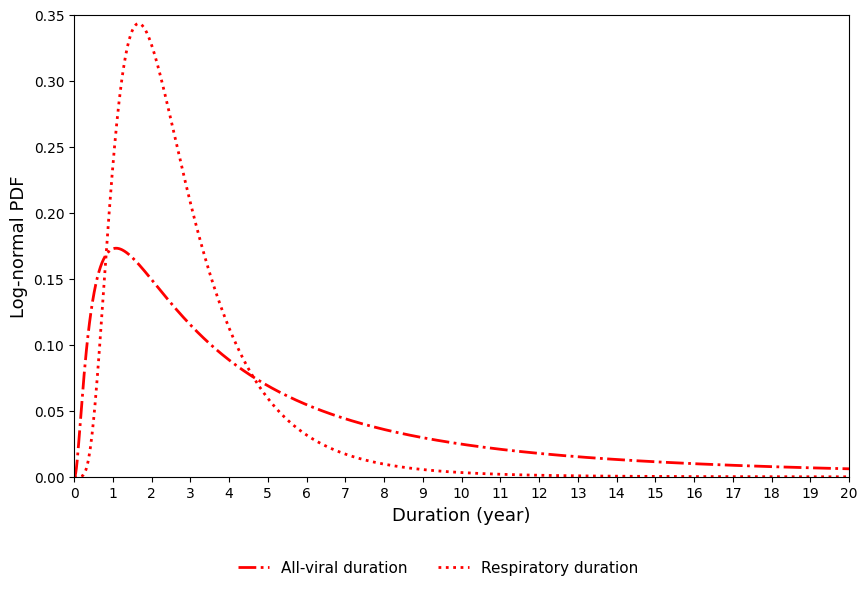

In [39]:

## Plot duration densities for all-viral and respiratory
plt.figure(figsize=(10, 6))

## Plot all-viral duration density
plt.plot(x, pdf_all, 'r-.', lw=2, label=f'All-viral duration')
plt.plot(x, pdf_resp, 'r:', lw=2, label=f'Respiratory duration')

plt.xticks(np.arange(0, 21))

plt.ylim(0, 0.35)
plt.xlim(0, 20)

plt.ylabel('Log-normal PDF', fontsize=13)
plt.xlabel('Duration (year)', fontsize=13)

## Adding legend below the plot in 'ncol' column(s) without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=2, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
# plt.savefig('graphs/11_duration_lognorm.jpg', dpi=400, bbox_inches = 'tight')

plt.show()
